In [1]:
import os, glob, math
from io import BytesIO

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import nugraph as ng

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
except Exception as e:
    EventAccumulator = None
    print("Could not import TensorBoard EventAccumulator:", e)

torch.set_float32_matmul_precision("medium")

DATA_PATH = "/home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly"
RUN_NAME = "merged1_Aug21_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5"
RUN_DIR = f"/home/apaudel/NuGraph/logs/{RUN_NAME}"

ckpts = glob.glob(f"{RUN_DIR}/**/*.ckpt", recursive=True)
assert ckpts, f"No checkpoint found under {RUN_DIR}"
CKPT = max(ckpts, key=os.path.getmtime)

event_files = glob.glob(f"{RUN_DIR}/**/events.out.tfevents.*", recursive=True)
print("DATA_PATH =", DATA_PATH)
print("RUN_NAME  =", RUN_NAME)
print("RUN_DIR   =", RUN_DIR)
print("CKPT      =", CKPT)
print("event files =", len(event_files))

raw = torch.load(CKPT, map_location="cpu")
hp = raw.get("hyper_parameters", {})

print("\nCheckpoint hparams:")
for k in [
    "semantic_head", "vertex_head", "direction_head", "event_head",
    "sp_features", "use_optical", "use_pmt_pmt"
]:
    print(f"{k:16s} =", hp.get(k, "MISSING"))

Data = ng.data.H5DataModule
Model = ng.models.NuGraph3

nudata = Data(
    DATA_PATH,
    batch_size=64,
    num_workers=0,
    model=Model,
    shuffle="random",
    featext3d=True,
)

model = Model.load_from_checkpoint(CKPT)
model.eval()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("\nDataset lengths:")
print("train =", len(nudata.train_dataset))
print("val   =", len(nudata.val_dataset))
print("test  =", len(nudata.test_dataset))

print("\nModel sanity:")
print("use_optical =", model.use_optical)
print("PMT-PMT active =", model.optical_net.use_pmt_pmt if hasattr(model, "optical_net") else None)
print("sp_net active =", model.encoder.sp_net is not None)

DATA_PATH = /home/apaudel/NuGraph/scripts/merged1_Aug6_40k_pmtpmt_g4lepdir_with_vpred_nexusonly
RUN_NAME  = merged1_Aug21_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5
RUN_DIR   = /home/apaudel/NuGraph/logs/merged1_Aug21_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5
CKPT      = /home/apaudel/NuGraph/logs/merged1_Aug21_40k_g4lepdir_tpc_pds_semantic_vertex_direction_axisloss_fixedvpred_nexusfeat_pmtpmt_ep100_bs64_in8_sp5/version_0/checkpoints/epoch=99-step=47000.ckpt
event files = 1

Checkpoint hparams:
semantic_head    = True
vertex_head      = True
direction_head   = True
event_head       = False
sp_features      = 5
use_optical      = True
use_pmt_pmt      = True

Dataset lengths:
train = 30080
val   = 1672
test  = 1672

Model sanity:
use_optical = True
PMT-PMT active = True
sp_net active = True


,N test,axis cos mean,axis cos median,axis angle mean deg,axis angle median deg,axis angle p68 deg,axis angle p90 deg,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,...,axis uy abs mean,axis uz abs mean,pred vertex mean err cm,pred vertex median err cm,pred vertex p68 err cm,pred vertex p90 err cm,fixed v_pred mean err cm,fixed v_pred median err cm,fixed v_pred p68 err cm,fixed v_pred p90 err cm
0,1672,0.6622,0.7499,43.748798,41.416401,56.186001,79.231102,0.0634,0.2028,0.3487,...,0.3609,0.3688,185.465698,185.049698,249.478394,331.638,8.3818,5.4797,8.1207,17.76


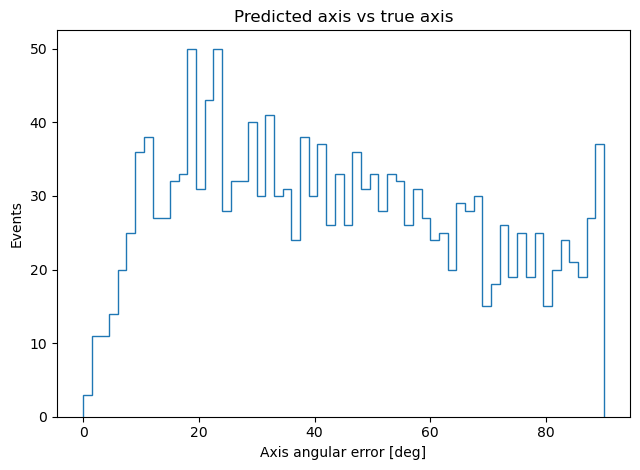

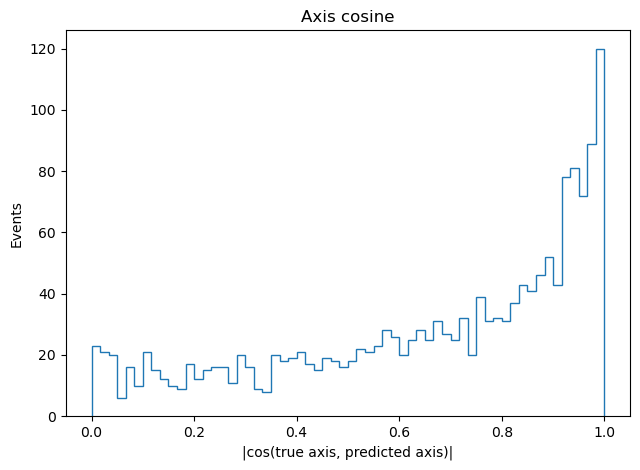

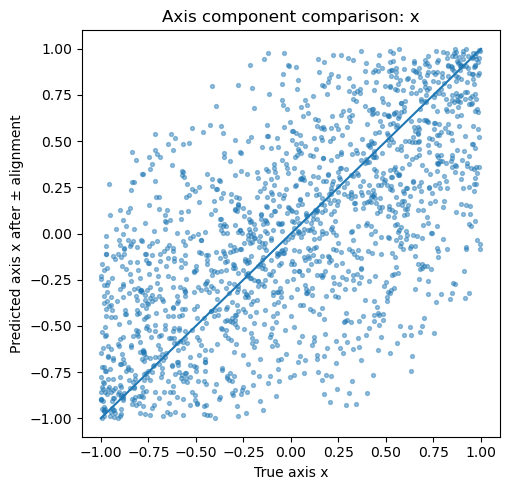

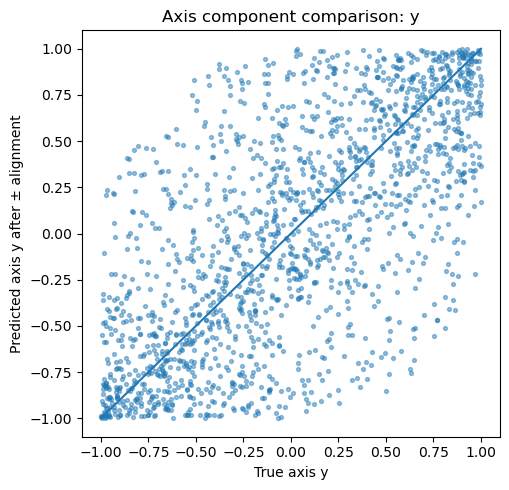

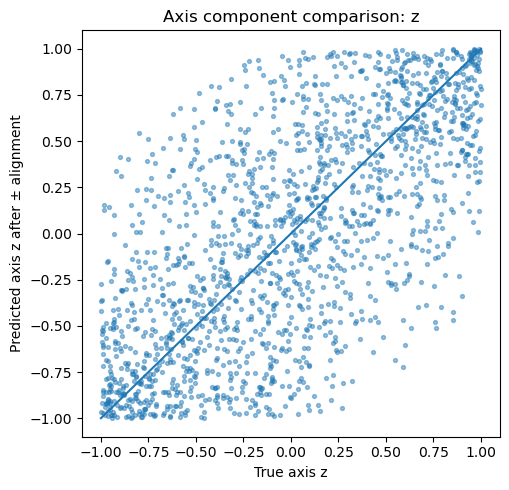

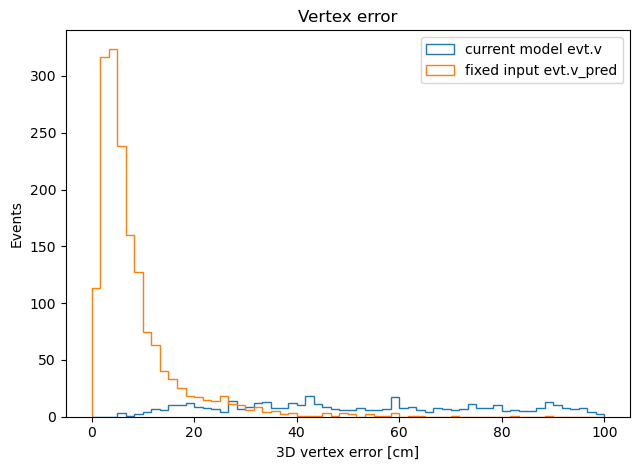

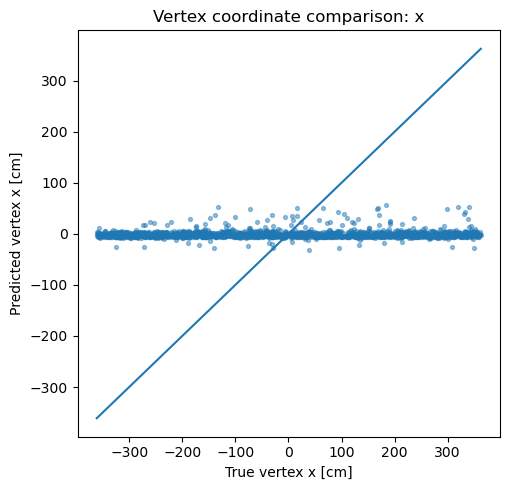

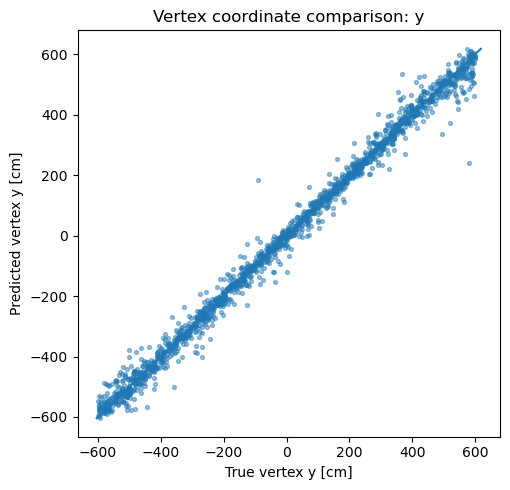

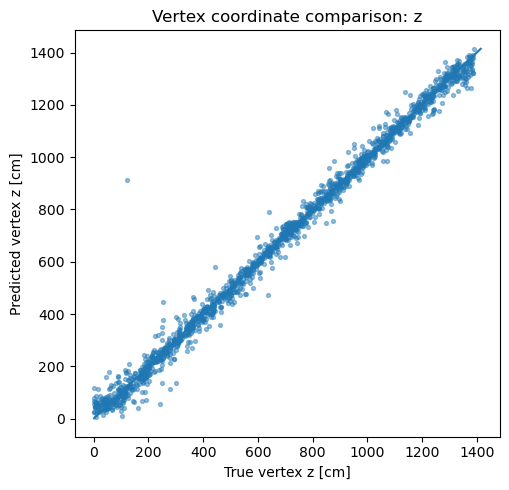


========== TensorBoard logged images ==========
No PNG/JPG image files found under RUN_DIR.
TensorBoard image tags: []

========== TensorBoard scalar curves ==========
Number of scalar tags = 0


In [2]:
# ============================================================
# 1. Evaluate model on test set
# ============================================================

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),

            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),
            "pred_vtx": evt.v.detach().float().cpu().numpy(),
            "fixed_vpred": evt.v_pred.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)
pred_vtx = np.concatenate([r["pred_vtx"] for r in rows], axis=0)
fixed_vpred = np.concatenate([r["fixed_vpred"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis evaluation: +u and -u are equivalent.
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Align predicted axis only for component comparison plots.
axis_sign = np.where(cos_signed >= 0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

axis_component_abs = np.abs(pred_axis_aligned - true_axis)

pred_vtx_err = np.linalg.norm(pred_vtx - true_vtx, axis=1)
fixed_vpred_err = np.linalg.norm(fixed_vpred - true_vtx, axis=1)

summary = {
    "N test": len(axis_angle_deg),

    "axis cos mean": np.mean(axis_cos),
    "axis cos median": np.median(axis_cos),
    "axis angle mean deg": np.mean(axis_angle_deg),
    "axis angle median deg": np.median(axis_angle_deg),
    "axis angle p68 deg": np.percentile(axis_angle_deg, 68),
    "axis angle p90 deg": np.percentile(axis_angle_deg, 90),
    "frac axis angle < 10 deg": np.mean(axis_angle_deg < 10),
    "frac axis angle < 20 deg": np.mean(axis_angle_deg < 20),
    "frac axis angle < 30 deg": np.mean(axis_angle_deg < 30),

    "axis ux abs mean": axis_component_abs[:, 0].mean(),
    "axis uy abs mean": axis_component_abs[:, 1].mean(),
    "axis uz abs mean": axis_component_abs[:, 2].mean(),

    "pred vertex mean err cm": pred_vtx_err.mean(),
    "pred vertex median err cm": np.median(pred_vtx_err),
    "pred vertex p68 err cm": np.percentile(pred_vtx_err, 68),
    "pred vertex p90 err cm": np.percentile(pred_vtx_err, 90),

    "fixed v_pred mean err cm": fixed_vpred_err.mean(),
    "fixed v_pred median err cm": np.median(fixed_vpred_err),
    "fixed v_pred p68 err cm": np.percentile(fixed_vpred_err, 68),
    "fixed v_pred p90 err cm": np.percentile(fixed_vpred_err, 90),
}

display(pd.DataFrame([summary]).round(4))

# ============================================================
# 2. Direction axis plots: true vs predicted
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.xlabel("Axis angular error [deg]")
plt.ylabel("Events")
plt.title("Predicted axis vs true axis")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("Axis cosine")
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_axis[:, coord], pred_axis_aligned[:, coord], s=8, alpha=0.45)
    plt.plot([-1, 1], [-1, 1])
    plt.xlabel(f"True axis {label}")
    plt.ylabel(f"Predicted axis {label} after ± alignment")
    plt.title(f"Axis component comparison: {label}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Vertex plots: true vs predicted
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(pred_vtx_err, bins=60, range=(0, 100), histtype="step", label="current model evt.v")
plt.hist(fixed_vpred_err, bins=60, range=(0, 100), histtype="step", label="fixed input evt.v_pred")
plt.xlabel("3D vertex error [cm]")
plt.ylabel("Events")
plt.title("Vertex error")
plt.legend()
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    lo = min(true_vtx[:, coord].min(), pred_vtx[:, coord].min())
    hi = max(true_vtx[:, coord].max(), pred_vtx[:, coord].max())

    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_vtx[:, coord], pred_vtx[:, coord], s=8, alpha=0.45)
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel(f"True vertex {label} [cm]")
    plt.ylabel(f"Predicted vertex {label} [cm]")
    plt.title(f"Vertex coordinate comparison: {label}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 4. Show TensorBoard logged images, if any
# ============================================================

print("\n========== TensorBoard logged images ==========")

image_files = []
for ext in ["png", "jpg", "jpeg"]:
    image_files += glob.glob(f"{RUN_DIR}/**/*.{ext}", recursive=True)

if image_files:
    print(f"Found {len(image_files)} image files under RUN_DIR")
    for f in sorted(image_files):
        print(f)
        img = Image.open(f)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.relpath(f, RUN_DIR))
        plt.tight_layout()
        plt.show()
else:
    print("No PNG/JPG image files found under RUN_DIR.")

if EventAccumulator is not None and event_files:
    acc = EventAccumulator(RUN_DIR, size_guidance={"images": 0, "scalars": 0})
    acc.Reload()
    tags = acc.Tags()

    image_tags = tags.get("images", [])
    print("TensorBoard image tags:", image_tags)

    for tag in image_tags:
        imgs = acc.Images(tag)
        print(f"\nImage tag: {tag}, N = {len(imgs)}")

        for i, im in enumerate(imgs):
            img = Image.open(BytesIO(im.encoded_image_string))
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{tag}, step={im.step}, index={i}")
            plt.tight_layout()
            plt.show()
else:
    print("TensorBoard EventAccumulator unavailable or no event files found.")

# ============================================================
# 5. Show all TensorBoard scalar curves
# ============================================================

print("\n========== TensorBoard scalar curves ==========")

if EventAccumulator is not None and event_files:
    scalar_tags = acc.Tags().get("scalars", [])
    print(f"Number of scalar tags = {len(scalar_tags)}")

    scalar_data = {}
    for tag in scalar_tags:
        evs = acc.Scalars(tag)
        scalar_data[tag] = (
            np.array([e.step for e in evs]),
            np.array([e.value for e in evs]),
        )

    # Plot all scalar curves, grouped 6 per figure.
    tags_sorted = sorted(scalar_tags)
    group_size = 6

    for start in range(0, len(tags_sorted), group_size):
        group = tags_sorted[start:start + group_size]

        plt.figure(figsize=(8, 4.8))
        for tag in group:
            steps, vals = scalar_data[tag]
            plt.plot(steps, vals, label=tag)

        plt.xlabel("Step")
        plt.ylabel("Value")
        plt.title("TensorBoard scalar logs")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print("No scalar curves shown.")

,N test,axis cos mean,axis cos median,axis angle mean deg,axis angle median deg,axis angle p68 deg,axis angle p90 deg,frac axis angle < 10 deg,frac axis angle < 20 deg,frac axis angle < 30 deg,...,axis uy abs mean,axis uz abs mean,pred vertex mean err cm,pred vertex median err cm,pred vertex p68 err cm,pred vertex p90 err cm,fixed v_pred mean err cm,fixed v_pred median err cm,fixed v_pred p68 err cm,fixed v_pred p90 err cm
0,1672,0.6621,0.7492,43.749001,41.475201,56.186001,79.231102,0.0634,0.2028,0.3487,...,0.3609,0.3688,185.465698,185.049896,249.478302,331.638,8.3818,5.4797,8.1207,17.76


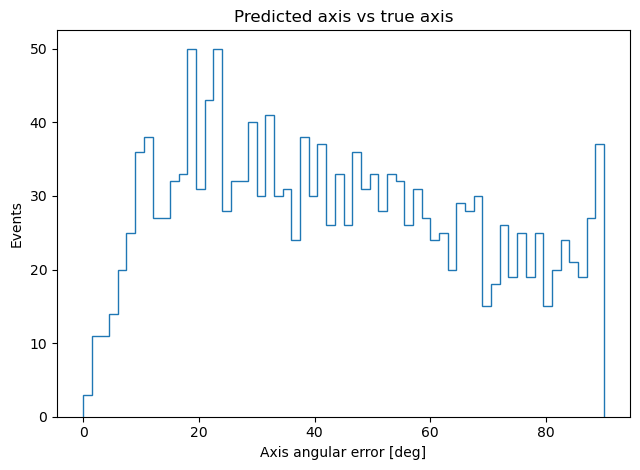

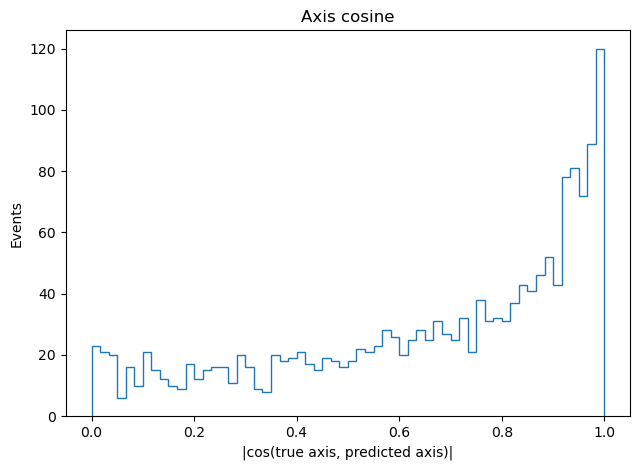

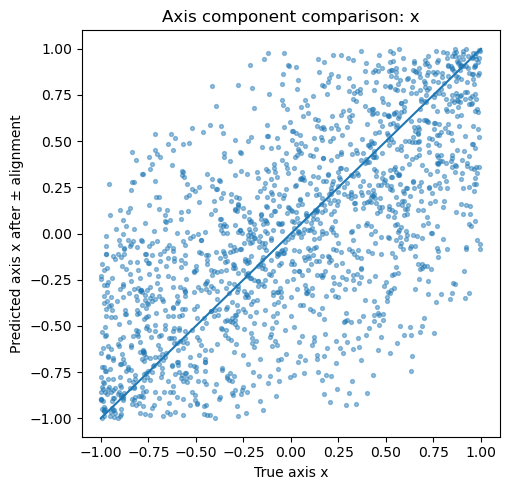

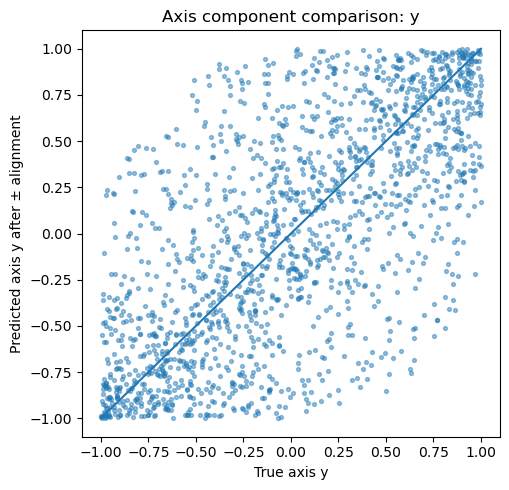

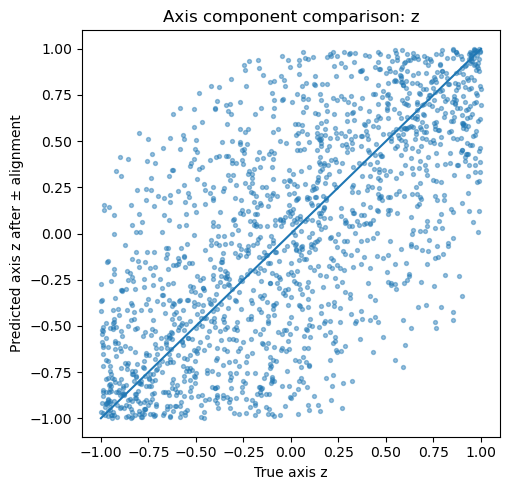

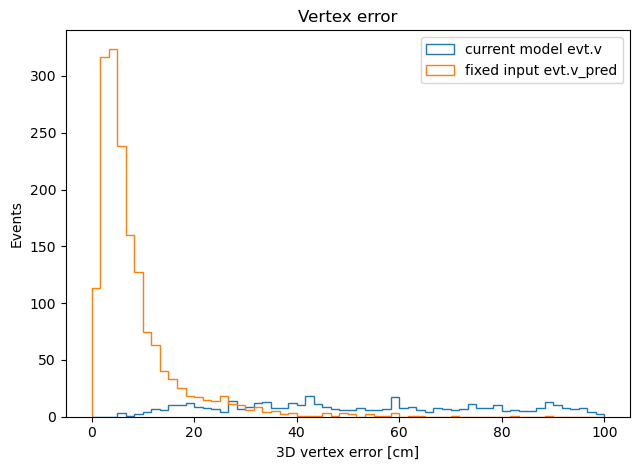

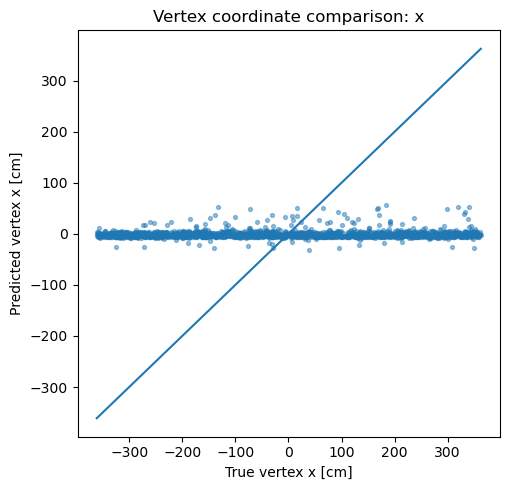

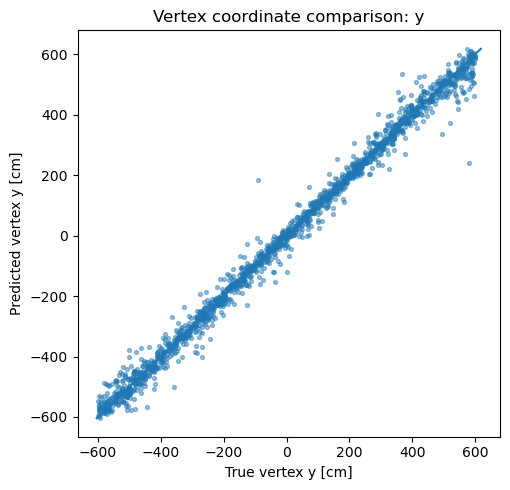

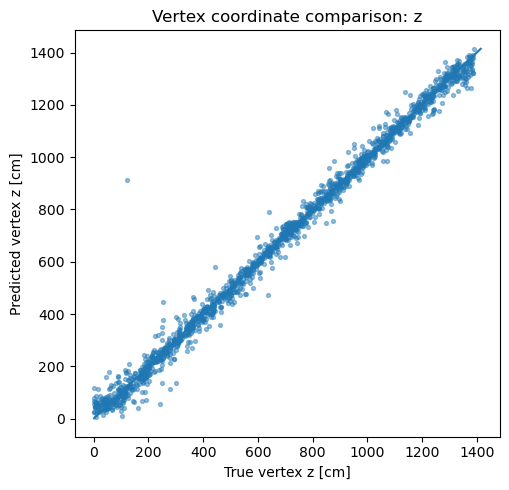


========== TensorBoard logged images ==========
No PNG/JPG image files found under RUN_DIR.
TensorBoard image tags: []

========== TensorBoard scalar curves ==========
Number of scalar tags = 0


In [3]:
# ============================================================
# 1. Evaluate model on test set
# ============================================================

rows = []

with torch.no_grad():
    for batch in nudata.test_dataloader():
        batch = batch.to(device)
        model(batch, "test")

        evt = batch["evt"]

        rows.append({
            "true_dir": evt.y_dir.detach().float().cpu().numpy(),
            "pred_dir": evt.d.detach().float().cpu().numpy(),

            "true_vtx": evt.y_vtx.detach().float().cpu().numpy(),
            "pred_vtx": evt.v.detach().float().cpu().numpy(),
            "fixed_vpred": evt.v_pred.detach().float().cpu().numpy(),
        })

true_dir = np.concatenate([r["true_dir"] for r in rows], axis=0)
pred_dir = np.concatenate([r["pred_dir"] for r in rows], axis=0)

true_vtx = np.concatenate([r["true_vtx"] for r in rows], axis=0)
pred_vtx = np.concatenate([r["pred_vtx"] for r in rows], axis=0)
fixed_vpred = np.concatenate([r["fixed_vpred"] for r in rows], axis=0)

def unit(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, 1.0e-12, None)

true_axis = unit(true_dir)
pred_axis = unit(pred_dir)

# Axis evaluation: +u and -u are equivalent.
cos_signed = np.sum(true_axis * pred_axis, axis=1)
cos_signed = np.clip(cos_signed, -1.0, 1.0)

axis_cos = np.abs(cos_signed)
axis_angle_deg = np.degrees(np.arccos(axis_cos))

# Align predicted axis only for component comparison plots.
axis_sign = np.where(cos_signed >= 0, 1.0, -1.0)[:, None]
pred_axis_aligned = pred_axis * axis_sign

axis_component_abs = np.abs(pred_axis_aligned - true_axis)

pred_vtx_err = np.linalg.norm(pred_vtx - true_vtx, axis=1)
fixed_vpred_err = np.linalg.norm(fixed_vpred - true_vtx, axis=1)

summary = {
    "N test": len(axis_angle_deg),

    "axis cos mean": np.mean(axis_cos),
    "axis cos median": np.median(axis_cos),
    "axis angle mean deg": np.mean(axis_angle_deg),
    "axis angle median deg": np.median(axis_angle_deg),
    "axis angle p68 deg": np.percentile(axis_angle_deg, 68),
    "axis angle p90 deg": np.percentile(axis_angle_deg, 90),
    "frac axis angle < 10 deg": np.mean(axis_angle_deg < 10),
    "frac axis angle < 20 deg": np.mean(axis_angle_deg < 20),
    "frac axis angle < 30 deg": np.mean(axis_angle_deg < 30),

    "axis ux abs mean": axis_component_abs[:, 0].mean(),
    "axis uy abs mean": axis_component_abs[:, 1].mean(),
    "axis uz abs mean": axis_component_abs[:, 2].mean(),

    "pred vertex mean err cm": pred_vtx_err.mean(),
    "pred vertex median err cm": np.median(pred_vtx_err),
    "pred vertex p68 err cm": np.percentile(pred_vtx_err, 68),
    "pred vertex p90 err cm": np.percentile(pred_vtx_err, 90),

    "fixed v_pred mean err cm": fixed_vpred_err.mean(),
    "fixed v_pred median err cm": np.median(fixed_vpred_err),
    "fixed v_pred p68 err cm": np.percentile(fixed_vpred_err, 68),
    "fixed v_pred p90 err cm": np.percentile(fixed_vpred_err, 90),
}

display(pd.DataFrame([summary]).round(4))

# ============================================================
# 2. Direction axis plots: true vs predicted
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_angle_deg, bins=60, range=(0, 90), histtype="step")
plt.xlabel("Axis angular error [deg]")
plt.ylabel("Events")
plt.title("Predicted axis vs true axis")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.5, 4.8))
plt.hist(axis_cos, bins=60, range=(0, 1), histtype="step")
plt.xlabel("|cos(true axis, predicted axis)|")
plt.ylabel("Events")
plt.title("Axis cosine")
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_axis[:, coord], pred_axis_aligned[:, coord], s=8, alpha=0.45)
    plt.plot([-1, 1], [-1, 1])
    plt.xlabel(f"True axis {label}")
    plt.ylabel(f"Predicted axis {label} after ± alignment")
    plt.title(f"Axis component comparison: {label}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Vertex plots: true vs predicted
# ============================================================

plt.figure(figsize=(6.5, 4.8))
plt.hist(pred_vtx_err, bins=60, range=(0, 100), histtype="step", label="current model evt.v")
plt.hist(fixed_vpred_err, bins=60, range=(0, 100), histtype="step", label="fixed input evt.v_pred")
plt.xlabel("3D vertex error [cm]")
plt.ylabel("Events")
plt.title("Vertex error")
plt.legend()
plt.tight_layout()
plt.show()

for coord, label in [(0, "x"), (1, "y"), (2, "z")]:
    lo = min(true_vtx[:, coord].min(), pred_vtx[:, coord].min())
    hi = max(true_vtx[:, coord].max(), pred_vtx[:, coord].max())

    plt.figure(figsize=(5.2, 5.0))
    plt.scatter(true_vtx[:, coord], pred_vtx[:, coord], s=8, alpha=0.45)
    plt.plot([lo, hi], [lo, hi])
    plt.xlabel(f"True vertex {label} [cm]")
    plt.ylabel(f"Predicted vertex {label} [cm]")
    plt.title(f"Vertex coordinate comparison: {label}")
    plt.tight_layout()
    plt.show()

# ============================================================
# 4. Show TensorBoard logged images, if any
# ============================================================

print("\n========== TensorBoard logged images ==========")

image_files = []
for ext in ["png", "jpg", "jpeg"]:
    image_files += glob.glob(f"{RUN_DIR}/**/*.{ext}", recursive=True)

if image_files:
    print(f"Found {len(image_files)} image files under RUN_DIR")
    for f in sorted(image_files):
        print(f)
        img = Image.open(f)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.relpath(f, RUN_DIR))
        plt.tight_layout()
        plt.show()
else:
    print("No PNG/JPG image files found under RUN_DIR.")

if EventAccumulator is not None and event_files:
    acc = EventAccumulator(RUN_DIR, size_guidance={"images": 0, "scalars": 0})
    acc.Reload()
    tags = acc.Tags()

    image_tags = tags.get("images", [])
    print("TensorBoard image tags:", image_tags)

    for tag in image_tags:
        imgs = acc.Images(tag)
        print(f"\nImage tag: {tag}, N = {len(imgs)}")

        for i, im in enumerate(imgs):
            img = Image.open(BytesIO(im.encoded_image_string))
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{tag}, step={im.step}, index={i}")
            plt.tight_layout()
            plt.show()
else:
    print("TensorBoard EventAccumulator unavailable or no event files found.")

# ============================================================
# 5. Show all TensorBoard scalar curves
# ============================================================

print("\n========== TensorBoard scalar curves ==========")

if EventAccumulator is not None and event_files:
    scalar_tags = acc.Tags().get("scalars", [])
    print(f"Number of scalar tags = {len(scalar_tags)}")

    scalar_data = {}
    for tag in scalar_tags:
        evs = acc.Scalars(tag)
        scalar_data[tag] = (
            np.array([e.step for e in evs]),
            np.array([e.value for e in evs]),
        )

    # Plot all scalar curves, grouped 6 per figure.
    tags_sorted = sorted(scalar_tags)
    group_size = 6

    for start in range(0, len(tags_sorted), group_size):
        group = tags_sorted[start:start + group_size]

        plt.figure(figsize=(8, 4.8))
        for tag in group:
            steps, vals = scalar_data[tag]
            plt.plot(steps, vals, label=tag)

        plt.xlabel("Step")
        plt.ylabel("Value")
        plt.title("TensorBoard scalar logs")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print("No scalar curves shown.")